In [ ]:
from google.colab import drive #files are in my google drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os #just finding the exact file name here
for file in os.listdir("/content/drive/MyDrive"):
    print(file)

Getting started.pdf
Graph.gsheet
Lily Donaldson Personal Statement.docx
Copy of Lily Donaldson Personal Statement.docx
5PAM2000 - Instrumentation (1).pptx
SpaceScienceGrouptemplate2024 (1).docx
5PAM2000 - Thermal Control (2) (1).pptx
Lunar_Impact_Crater_Database.xlsx
SpaceScienceGrouptemplate2024 (2).docx
SpaceScienceGrouptemplate2024 (3).docx
Witold Niemczak Quantum Physics Presentation.pptx
2025-03-24_Donaldson_Transfer Request Form V6.docx
2025-03-24_Donaldson_Transfer Request Form V6 (1).docx
Untitled spreadsheet.gsheet
Colab Notebooks
simbad_bright_galaxies.xlsx
simbad_bright_galaxies.gsheet
Untitled presentation.gslides
initial_plan_feedback_Lily.docx
research-skills-section-new-application-form.docx
physics-astronomy-template-personal-statement.docx
research-skills-section-new-application-form (1).docx
research_skills (1).docx
final_table_cand.gsheet
targets.csv
Main Sequence A-M star data.xlsm
pop 3 stars.pptx
vista_raw
2026-03-24_Donaldson_Transfer Request Form V6 (1).docx
Lil

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/wetransfer_swot_l2_hr_pixc_001_475_244r_20230807t044016_20230807t044027_pgd0_01-nc_2026-07-02_1554.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/SWOT") #unzippinggggg

print("unzipped!")

unzipped!


In [ ]:
import os #seeing what we have now
os.listdir("/content/SWOT")

['SWOT_L2_HR_PIXC_014_169_244L_20240423T120331_20240423T120342_PGD0_01.nc',
 'SWOT_L2_HR_PIXC_001_475_244R_20230807T044016_20230807T044027_PGD0_01.nc']

In [ ]:
import os # i genuinely used these first bits of code maybe 80000 times for my diss so have them saved

for root, dirs, files in os.walk("/content/SWOT"):
    for file in files:
        if file.endswith(".nc"):
            print(os.path.join(root, file))

/content/SWOT/SWOT_L2_HR_PIXC_014_169_244L_20240423T120331_20240423T120342_PGD0_01.nc
/content/SWOT/SWOT_L2_HR_PIXC_001_475_244R_20230807T044016_20230807T044027_PGD0_01.nc


Two different swot files, will inspect both individually and compare. First thought is maybe left and right? Based on the names.

In [ ]:
file1 = "/content/SWOT/SWOT_L2_HR_PIXC_001_475_244R_20230807T044016_20230807T044027_PGD0_01.nc"
file2 = "/content/SWOT/SWOT_L2_HR_PIXC_014_169_244L_20240423T120331_20240423T120342_PGD0_01.nc"

#reassigning so its a bit easier



In [ ]:
import xarray as xr
ds = xr.open_dataset(file1) #opening first one (right one?), want everything
print(ds)

<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*
Attributes: (12/65)
    Conventions:                                            CF-1.7
    title:                                                  Level 2 KaRIn Hig...
    institution:                                            JPL
    source:                                                 Ka-band radar int...
    history:                                                2025-10-29T13:22:...
    platform:                                               SWOT
    ...                                                     ...
    xref_pole_location_file:                                SMM_PO1_AXXCNE202...
    xref_geco_database_version:                             v107
    ellipsoid_semi_major_axis:                              6378137.0
    ellipsoid_flattening:                                   0.003352810664747...
    references:                                             1.4.2
    product_version:                        

Can see so far its level 2 data. Seems like just metadata?

In [ ]:
!pip install netCDF4 #Had to do some reserach here.

In [ ]:
import netCDF4

nc = netCDF4.Dataset(file1)
print(nc)

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    Conventions: CF-1.7
    title: Level 2 KaRIn High Rate Water Mask Pixel Cloud Data Product
    institution: JPL
    source: Ka-band radar interferometer
    history: 2025-10-29T13:22:53Z : Creation
    platform: SWOT
    reference_document: D-56411_SWOT_Product_Description_L2_HR_PIXC
    contact: podaac@podaac.jpl.nasa.gov
    cycle_number: 1
    pass_number: 475
    tile_number: 244
    swath_side: R
    tile_name: 475_244R
    short_name: L2_HR_PIXC
    crid: PGD0
    pge_name: PGE_L2_HR_PIXC
    pge_version: 5.4.2
    time_granule_start: 2023-08-07T04:40:16.885826Z
    time_granule_end: 2023-08-07T04:40:27.984491Z
    time_coverage_start: 2023-08-07T04:40:17.433135Z
    time_coverage_end: 2023-08-07T04:40:27.437182Z
    geospatial_lon_min: -4.22298626387402
    geospatial_lon_max: -3.0587064474653403
    geospatial_lat_min: 50.20920827989779
    geospatial_lat_max: 50.99102671456954
    inner_first_long

3 main groups? pixel_cloud, tvp and noise. So far can see location via lat and lon - in west England I assume.

In [ ]:
#inspecting first one! pixel_cloud
ds = xr.open_dataset(file1, group="pixel_cloud")

print(ds)

<xarray.Dataset> Size: 2GB
Dimensions:                                (points: 7344105, complex_depth: 2,
                                            num_pixc_lines: 3265)
Coordinates:
    latitude                               (points) float64 59MB ...
    longitude                              (points) float64 59MB ...
Dimensions without coordinates: points, complex_depth, num_pixc_lines
Data variables: (12/62)
    azimuth_index                          (points) float64 59MB ...
    range_index                            (points) float64 59MB ...
    interferogram                          (points, complex_depth) float32 59MB ...
    power_plus_y                           (points) float32 29MB ...
    power_minus_y                          (points) float32 29MB ...
    coherent_power                         (points) float32 29MB ...
    ...                                     ...
    pixc_line_qual                         (num_pixc_lines) float64 26kB ...
    pixc_line_to_tvp         

er this is a lot of info, variable names next?

In [ ]:
for variable in ds.data_vars:
    print(variable)

azimuth_index
range_index
interferogram
power_plus_y
power_minus_y
coherent_power
x_factor_plus_y
x_factor_minus_y
water_frac
water_frac_uncert
classification
false_detection_rate
missed_detection_rate
prior_water_prob
prior_water_change
bright_land_flag
layover_impact
eff_num_rare_looks
height
cross_track
pixel_area
inc
phase_noise_std
dlatitude_dphase
dlongitude_dphase
dheight_dphase
dheight_droll
dheight_dbaseline
dheight_drange
darea_dheight
illumination_time
illumination_time_tai
eff_num_medium_looks
sig0
sig0_uncert
phase_unwrapping_region
ambiguity_cost1
ambiguity_cost2
instrument_range_cor
instrument_phase_cor
instrument_baseline_cor
sig0_cor_atmos_model
height_cor_xover
model_dry_tropo_cor
model_wet_tropo_cor
iono_cor_gim_ka
geoid
solid_earth_tide
load_tide_fes
load_tide_got
pole_tide
ancillary_surface_classification_flag
interferogram_qual
classification_qual
geolocation_qual
sig0_qual
pixc_line_qual
pixc_line_to_tvp
data_window_first_valid
data_window_last_valid
data_window_

Things that stick out to me and are interesting: height (of course), false and missed detection rates? geoid

In [ ]:
import matplotlib.pyplot as plt


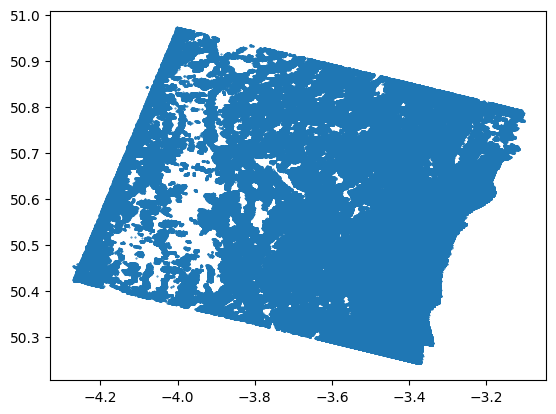

In [ ]:
plt.scatter( #first plot!!! starting w the basics, lat vs lon, tbh this is just to see what is going on
    ds.longitude,
    ds.latitude,
    s=0.2) #doing tiny points cus it kept glitching prob cus theres so much data
    #This is kind of the base plot i guess? trying to see thr properties for these coord so will map coords first.

Interesting - are the white points missing data? Why missing? Land/ bad quality? How can I find out ?


Ok so there's some that are water related ( what we need mostly!), will figure out what prior_water_prob is???? Lots to do w the radar like phase etc, need more inspection to work those out. Also some tide info etc. ALSO!!! some qual data - quality i assume.

Maybe put in a separate notebook just the plots.


In [ ]:
#ok looking at height next. inspect first
print(ds["height"])

<xarray.DataArray 'height' (points: 7344105)> Size: 29MB
[7344105 values with dtype=float32]
Coordinates:
    latitude   (points) float64 59MB 50.42 50.42 50.42 ... 50.79 50.79 50.79
    longitude  (points) float64 59MB -4.259 -4.259 -4.261 ... -3.112 -3.114
Dimensions without coordinates: points
Attributes:
    long_name:     height above reference ellipsoid
    units:         m
    quality_flag:  geolocation_qual
    valid_min:     -1500.0
    valid_max:     15000.0
    comment:       Height of the pixel above the reference ellipsoid.


ok looks like 7344105 rows of data w assigned lat and lon, is that our number of pulses maybe?

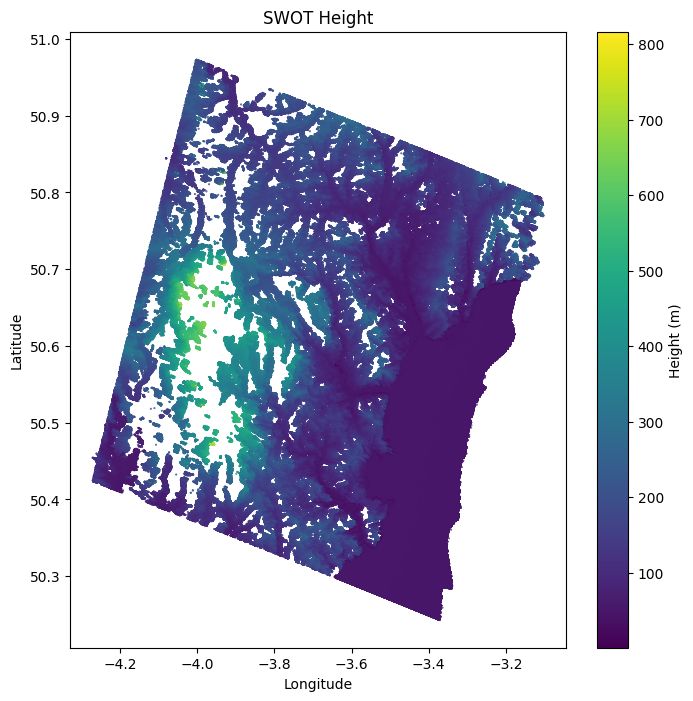

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8)) #This is just the standard size i use

plt.scatter(
    ds.longitude.values, #where
    ds.latitude.values,
    c=ds.height.values, #what colour so we can see
    s=0.2,
    cmap="viridis") #just the first one i found tbh

plt.colorbar(label="Height (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("SWOT Height")

plt.show() #er mega slow run time for all points, maybe reduce ? Every 10th point

Kind of want to see water frac? Is that whats land vs water? we can have a look vs the missing pixels maybe? The missing pixels SEEM like they're at higher height but idk need ti inspect more, water_frac and classification will look at next

Plot power coherence !! whats going on here and what does it mean. - side locking image?

Notes from meeting - subset data more, tighter range so colour axis adjusts (basically want more detail, maybe that would be good for water frac etc)?

In [ ]:
print(ds["water_frac"])

<xarray.DataArray 'water_frac' (points: 7344105)> Size: 29MB
[7344105 values with dtype=float32]
Coordinates:
    latitude   (points) float64 59MB 50.42 50.42 50.42 ... 50.79 50.79 50.79
    longitude  (points) float64 59MB -4.259 -4.259 -4.261 ... -3.112 -3.114
Dimensions without coordinates: points
Attributes:
    long_name:     water fraction
    units:         1
    quality_flag:  classification_qual
    valid_min:     -1000.0
    valid_max:     10000.0
    comment:       Noisy estimate of the fraction of the pixel that is water.


Okieee, noisy estimate? So could this be used to plot water ?????

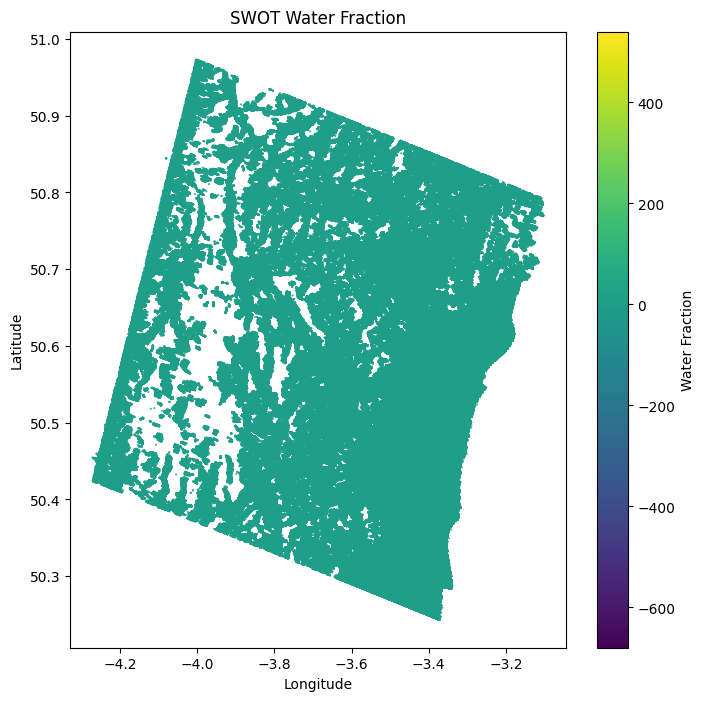

In [ ]:
import matplotlib.pyplot as plt
#reusing my base code hereeeeee
plt.figure(figsize=(8,8))

plt.scatter(
    ds.longitude.values, #where
    ds.latitude.values,
    c=ds.water_frac.values, #what colour so we can see
    s=0.2,
    cmap="viridis") #just the first one i found tbh

plt.colorbar(label="Water Fraction")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("SWOT Water Fraction")

plt.show()

ERRRRRRRRRRRRR, ok interesting lol same water fraction? Prob should have inspected actual values to see if they differ much but hey

Basically reusing my first code and just changing what variable i colour with.

In [ ]:
#What is classification???????? inspect then plot (I've learned from the water frac one)

In [ ]:
print(ds['classification'])



<xarray.DataArray 'classification' (points: 7344105)> Size: 29MB
[7344105 values with dtype=float32]
Coordinates:
    latitude   (points) float64 59MB 50.42 50.42 50.42 ... 50.79 50.79 50.79
    longitude  (points) float64 59MB -4.259 -4.259 -4.261 ... -3.112 -3.114
Dimensions without coordinates: points
Attributes:
    long_name:      classification
    quality_flag:   classification_qual
    flag_meanings:  land land_near_water water_near_land open_water dark_wate...
    flag_values:    [1 2 3 4 5 6 7]
    valid_min:      1
    valid_max:      7
    comment:        Flags indicating water detection results.


What does flag mean, maybe plot and try anf figure out which vals are which.

In [ ]:
ds.classification.values

array([1., 1., 1., ..., 1., 1., 1.], dtype=float32)

Ok this is probably why the plots look so one dimensional, flags seem to be pretty consistent - ask charlie!!, even through a range of 1-7 you would expect come colouring considering how many points and diff areas?

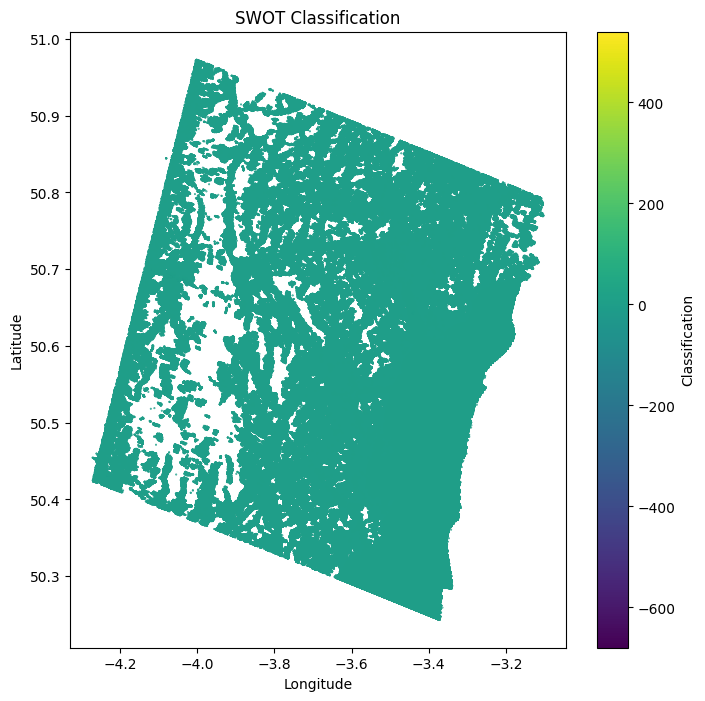

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.scatter(
    ds.longitude.values, #where
    ds.latitude.values,
    c=ds.water_frac.values, #what colour so we can see
    s=0.2,
    cmap="viridis") #just the first one i found tbh

plt.colorbar(label="Classification")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("SWOT Classification")

plt.show()

Continuing the flag hunt!!!


In [ ]:
ds["classification"]

<xarray.DataArray 'classification' (points: 7344105)> Size: 29MB
array([1., 1., 1., ..., 1., 1., 1.], dtype=float32)
Coordinates:
    latitude   (points) float64 59MB 50.42 50.42 50.42 ... 50.79 50.79 50.79
    longitude  (points) float64 59MB -4.259 -4.259 -4.261 ... -3.112 -3.114
Dimensions without coordinates: points
Attributes:
    long_name:      classification
    quality_flag:   classification_qual
    flag_meanings:  land land_near_water water_near_land open_water dark_wate...
    flag_values:    [1 2 3 4 5 6 7]
    valid_min:      1
    valid_max:      7
    comment:        Flags indicating water detection results.

In [ ]:
ds["classification_qual"]

<xarray.DataArray 'classification_qual' (points: 7344105)> Size: 59MB
[7344105 values with dtype=float64]
Coordinates:
    latitude   (points) float64 59MB 50.42 50.42 50.42 ... 50.79 50.79 50.79
    longitude  (points) float64 59MB -4.259 -4.259 -4.261 ... -3.112 -3.114
Dimensions without coordinates: points
Attributes:
    standard_name:  status_flag
    flag_meanings:  no_coherent_gain power_close_to_noise_floor detected_wate...
    flag_masks:     [         1          2          4          8         16  ...
    valid_min:      0
    valid_max:      3893160991
    comment:        Quality flag for the classification quantities in the pix...

ok looking at flag masks, what is that? a 2 power law? why?

In [ ]:
import numpy as np

np.unique(ds.classification_qual.values)

array([0.00000e+00, 1.00000e+00, 2.00000e+00, 3.00000e+00, 4.00000e+00,
       5.00000e+00, 6.00000e+00, 7.00000e+00, 8.00000e+00, 9.00000e+00,
       1.20000e+01, 1.30000e+01, 1.40000e+01, 1.50000e+01, 2.00000e+01,
       2.10000e+01, 2.20000e+01, 2.30000e+01, 2.80000e+01, 2.90000e+01,
       3.00000e+01, 2.04900e+03, 2.05100e+03, 2.05300e+03, 2.05500e+03,
       2.05700e+03, 2.06100e+03, 2.06900e+03, 2.07100e+03, 2.07700e+03,
       2.62144e+05, 2.62145e+05, 2.62146e+05, 2.62147e+05, 2.62148e+05,
       2.62149e+05, 2.62156e+05, 2.62157e+05, 2.64193e+05, 2.64195e+05,
       2.64197e+05, 2.64205e+05, 5.24288e+05, 5.24289e+05, 5.24290e+05,
       5.24291e+05, 5.24292e+05, 5.24293e+05, 5.24294e+05, 5.24295e+05,
       5.24300e+05, 5.24301e+05, 5.24308e+05, 5.24309e+05, 5.24310e+05,
       5.24311e+05, 5.24317e+05, 5.26337e+05, 5.26339e+05, 5.26341e+05,
       5.26349e+05, 5.26357e+05, 5.26359e+05, 5.26365e+05, 5.26367e+05,
       7.86432e+05, 7.86433e+05, 7.86434e+05, 7.86435e+05, 7.864

In [ ]:
#literally just picking one and seeing
mask = 2

flag = (ds.classification_qual.values.astype(np.int64) & mask) != 0

print(flag.sum())

1243746


In [ ]:
plt.figure(figsize=(8,8)) #Plotting power here!!!!

plt.scatter(
    ds.longitude.values,
    ds.latitude.values,
    c=flag,
    s=0.1,
    cmap="viridis")

plt.colorbar(label="Power")

Error in callback <function flush_figures at 0x79ec834e7060> (for post_execute):


KeyboardInterrupt: 

Investigating other qual things here

In [ ]:
ds["interferogram_qual"]

<xarray.DataArray 'interferogram_qual' (points: 7344105)> Size: 59MB
[7344105 values with dtype=float64]
Coordinates:
    latitude   (points) float64 59MB 50.42 50.42 50.42 ... 50.79 50.79 50.79
    longitude  (points) float64 59MB -4.259 -4.259 -4.261 ... -3.112 -3.114
Dimensions without coordinates: points
Attributes:
    standard_name:  status_flag
    flag_meanings:  suspect_karin_telem rare_power_suspect rare_phase_suspect...
    flag_masks:     [      1024       2048       4096       8192      16384  ...
    valid_min:      0
    valid_max:      4161600512
    comment:        Quality flag for the interferogram quantities in the pixe...

In [ ]:
ds["sig0_qual"]

<xarray.DataArray 'sig0_qual' (points: 7344105)> Size: 59MB
[7344105 values with dtype=float64]
Coordinates:
    latitude   (points) float64 59MB 50.42 50.42 50.42 ... 50.79 50.79 50.79
    longitude  (points) float64 59MB -4.259 -4.259 -4.261 ... -3.112 -3.114
Dimensions without coordinates: points
Attributes:
    standard_name:  status_flag
    flag_meanings:  sig0_uncert_suspect sig0_cor_atmos_suspect noise_power_su...
    flag_masks:     [         1          2          4          8       1024  ...
    valid_min:      0
    valid_max:      3994872847
    comment:        Quality flag for sig0

Right ok..... further work - maybe working out what % of the pixels are for each flag etc....

Trying diff colour scales, basically just removing the extreme values

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_map(var_name, label=None, cmap="viridis", lower=2, upper=98, s=0.1):
    var = ds[var_name].values #this is my core plotting code
    lon = ds.longitude.values
    lat = ds.latitude.values

    vmin = np.nanpercentile(var, lower) #this i did need ai to debug lol
    vmax = np.nanpercentile(var, upper)
    plt.figure(figsize=(8, 8))
    plt.scatter(
        lon, lat,
        c=var,
        s=s,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax)

    plt.colorbar(label=label or var_name)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(f"SWOT {var_name}")
    plt.show()

In [ ]:
plot_map("height", label="Height (m)", lower=5, upper=95)

KeyboardInterrupt: 

Hm looks better but a bit clunky? maybe reduce point size further

In [ ]:
plot_map("water_frac", label="Water fraction", cmap="viridis", lower=5, upper=95)

DIFFERENT COLOURSSSSS -  ok can so obviously tell whats sea and whats land, i think the height actually portrayed this better, maybe theres a way to compare height plot with sea level?

In [ ]:
plot_map("classification", label="Classification", cmap="viridis", lower=5, upper=95)

Have kind of been playinga round with upper and lower limits - would need visual or statistical inspection tbh, maybe a search in literature could show ?

Classification 4 seems to be water???? Land is 1? Book mentioned dark water? Explains the little pockets by the coast?

Hm? Dodgy points in the bottom corner?

In [ ]:
#inspecting power!!
ds["coherent_power"]

<xarray.DataArray 'coherent_power' (points: 7344105)> Size: 29MB
[7344105 values with dtype=float32]
Coordinates:
    latitude   (points) float64 59MB 50.42 50.42 50.42 ... 50.79 50.79 50.79
    longitude  (points) float64 59MB -4.259 -4.259 -4.261 ... -3.112 -3.114
Dimensions without coordinates: points
Attributes:
    long_name:     coherent power combination of minus_y and plus_y channels
    units:         1
    quality_flag:  interferogram_qual
    valid_min:     0.0
    valid_max:     1e+20
    comment:       Power computed by combining the plus_y and minus_y channel...

In [ ]:
plot_map("coherent_power", label="Coherent power", cmap="viridis", lower=15, upper=85)

okk so lower coherent power around what we infer to be the land areas. Maybe cus its rougher/vegetation? but appears more uniform here. Across the (potential) sea area - brighter so expected more coherent power AND we can see where it meets the coast as the coherent power starts to decline.

Kind of still not loving this scale, may decrease further?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "classification": ds.classification.values,
    "coherent_power": ds.coherent_power.values,
    "water_frac": ds.water_frac.values,
    "height": ds.height.values
})

df = df.replace([np.inf, -np.inf], np.nan).dropna()

df.groupby("classification")[["coherent_power", "water_frac", "height"]].median()
#interesting way to average but is it the best way?

,coherent_power,water_frac,height
classification,,,
1.0,3.283152e+05,-0.003890,144.945068
2.0,7.038056e+05,0.016905,126.915642
3.0,4.225931e+06,0.249151,112.750263
4.0,8.038430e+06,0.899123,49.709400
5.0,9.502465e+05,0.003698,50.376146
6.0,3.695775e+06,0.292561,122.322166
7.0,2.607506e+06,0.659557,109.398003


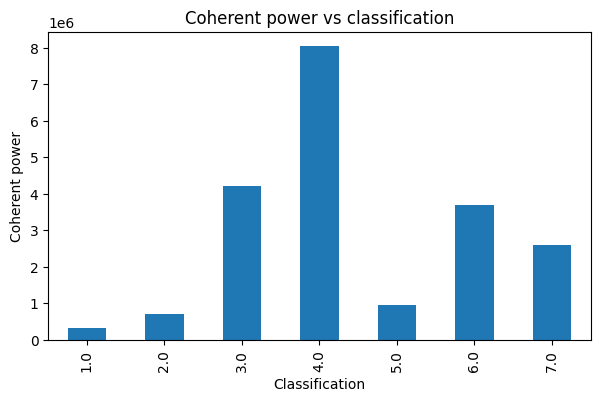

In [ ]:
df.groupby("classification")["coherent_power"].median().plot(kind="bar", figsize=(7,4))

plt.ylabel("Coherent power")
plt.xlabel("Classification")
plt.title("Coherent power vs classification")
plt.show()

ok THIS is interesting - kind of seeing where the majority of classifications are via power !

KML Stuff!!

In [ ]:
!pip install simplekml #i searched this up, ive never done kml before

In [ ]:


#four corners?

print(nc.getncattr("inner_first_longitude"))
print(nc.getncattr("inner_first_latitude"))

print(nc.getncattr("inner_last_longitude"))
print(nc.getncattr("inner_last_latitude"))

print(nc.getncattr("outer_first_longitude"))
print(nc.getncattr("outer_first_latitude"))

print(nc.getncattr("outer_last_longitude"))
print(nc.getncattr("outer_last_latitude"))

In [ ]:
import simplekml
kml = simplekml.Kml()

corners = [ #copied and pasted co-ords into here !
    (-4.22298626387402, 50.38166008964555),
    (-3.9273541321497305, 50.99102671456954),
    (-3.0587064474653403, 50.815023681409954),
    (-3.36699601395037, 50.20920827989779),
    (-4.22298626387402, 50.38166008964555)    ]

polygon = kml.newpolygon()
polygon.outerboundaryis = corners
kml.save("/content/SWOT_boundary.kml")

Last thing I want to look at is the phase stuff cus its to do w my project?

In [ ]:
phase_vars = [v for v in ds.data_vars if "phase" in v.lower()]
print(phase_vars) #everything to do  phase

['phase_noise_std', 'dlatitude_dphase', 'dlongitude_dphase', 'dheight_dphase', 'phase_unwrapping_region', 'instrument_phase_cor']


In [ ]:
for v in phase_vars: #this is basically just the previous phase headings and printing all the info for each
    print(v)
    print(ds[v])
    print()

phase_noise_std
<xarray.DataArray 'phase_noise_std' (points: 7344105)> Size: 29MB
[7344105 values with dtype=float32]
Coordinates:
    latitude   (points) float64 59MB 50.42 50.42 50.42 ... 50.79 50.79 50.79
    longitude  (points) float64 59MB -4.259 -4.259 -4.261 ... -3.112 -3.114
Dimensions without coordinates: points
Attributes:
    long_name:  phase noise standard deviation
    units:      radians
    valid_min:  -999999.0
    valid_max:  999999.0
    comment:    Estimate of the phase noise standard deviation.

dlatitude_dphase
<xarray.DataArray 'dlatitude_dphase' (points: 7344105)> Size: 29MB
[7344105 values with dtype=float32]
Coordinates:
    latitude   (points) float64 59MB 50.42 50.42 50.42 ... 50.79 50.79 50.79
    longitude  (points) float64 59MB -4.259 -4.259 -4.261 ... -3.112 -3.114
Dimensions without coordinates: points
Attributes:
    long_name:     sensitivity of latitude estimate to interferogram phase
    units:         degrees/radian
    quality_flag:  geolocation_q

In [ ]:
plot_map(
    "phase_noise_std",
    label="Phase noise std",
    cmap="viridis",
    lower=2,
    upper=98)

KeyboardInterrupt: 

Wait are there complex bits?

AH this one looks the most interesting terms of detail

In [ ]:
ds["interferogram"]

<xarray.DataArray 'interferogram' (points: 7344105, complex_depth: 2)> Size: 59MB
[14688210 values with dtype=float32]
Coordinates:
    latitude   (points) float64 59MB 50.42 50.42 50.42 ... 50.79 50.79 50.79
    longitude  (points) float64 59MB -4.259 -4.259 -4.261 ... -3.112 -3.114
Dimensions without coordinates: points, complex_depth
Attributes:
    long_name:     rare interferogram
    units:         1
    quality_flag:  interferogram_qual
    valid_min:     -1e+20
    valid_max:     1e+20
    comment:       Complex unflattened rare interferogram.

omg ok yeah maybe complex bits

In [ ]:


interf = ds["interferogram"].values

phase = np.arctan2(interf[:, 1], interf[:, 0])

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(
    ds.longitude.values,
    ds.latitude.values,
    c=phase,
    s=0.1,
    cmap="viridis")
plt.colorbar(label="Interferometric phase (rad)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("SWOT interferometric phase")
plt.show()

This one is... interesting. i dont really know what to make of it

SOOOOOO final notes: my next thing would be trying to isolate where the phase is actually siginifcant using the quality data???? is that helpful so just plotting phase where our phase quality seems ok ? but what would the standard be etc.... stats to go into

Fringes due to the wrapping - unwrap w algorithms !! More research?

Next step is isolating part of the ocean and then trying to come up with an unwrapping algorithm.

In [ ]:
#stole this from sci-kit image.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.restoration import unwrap_phase

In [ ]:
interf = ds["interferogram"].values
#complex bits
phase = np.angle(interf[:, 0] + 1j * interf[:, 1])

In [ ]:
lon = ds.longitude.values
lat = ds.latitude.values

ocean_mask = (
    (lon > -3.45) &
    (lon < -3.15) &
    (lat > 50.25) &
    (lat < 50.60)
)

So making a zoomed in section of the plotttt, just kind of picked co-ords in the bottom and plotting to check (could even compare to classification or water frac to confirm)

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(lon[ocean_mask], lat[ocean_mask], c=phase[ocean_mask], s=0.2, cmap = "viridis")
plt.colorbar(label="Wrapped phase (rad)")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Selected ocean region: wrapped phase")
plt.show()

Fringes super obvious!!

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.restoration import unwrap_phase
interf = ds["interferogram"].values

phase = np.angle(interf[:, 0] + 1j * interf[:, 1])

In [ ]:
lon = ds.longitude.values
lat = ds.latitude.values

ocean_mask = (
    (lon > -3.45) &
    (lon < -3.30) &
    (lat > 50.25) &
    (lat < 50.60)
)

In [ ]:
plt.figure(figsize=(7,7))
plt.scatter(lon[ocean_mask], lat[ocean_mask], c=phase[ocean_mask], s=0.2, cmap="viridis")
plt.colorbar(label="Wrapped phase (rad)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Selected ocean region: wrapped phase")
plt.show()